# Notebook 1 — PI's proposed approach: per-metric ±1 SD classification

**The plan, as proposed:**
1. Keep only *old* animals.
2. For every circadian metric, plot a Gaussian curve.
3. Animals outside **±1 SD** from the mean → **vulnerable**.
4. Animals within ±1 SD → **resilient**.
5. Compare the two groups on the main behavioural metrics.

This notebook implements that plan **faithfully**, and along the way flags the
statistical problems that arise. It is meant as a demonstration of *why* this
specific classification rule is not defensible — not as a final analysis.

Circadian metrics analysed: `IS`, `IV`, `RA`, `Amplitude` (PRE and POST).
Behavioural metrics: Barnes T6 entries, Barnes learning slope, NOR discrimination index.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_context("notebook")
sns.set_style("whitegrid")

REPO = Path.cwd().parent.parent  # notebook lives at poster_analysis/vulnerability_resilience_analysis/

# Circadian_raw has ID, PRE_POST, metrics, Age_new, Sex_new, Light_new
circ = pd.read_csv(REPO / "Circadian_raw.csv").rename(columns={"PRE.POST": "PRE_POST"})
metrics_base = ["IS", "IV", "RA", "Amplitude"]
wide = circ.pivot_table(
    index="ID", columns="PRE_POST", values=metrics_base
)
wide.columns = [f"{m}_{p.lower()}" for m, p in wide.columns]
wide = wide.reset_index()

grp = (
    circ[["ID", "Sex_new", "Age_new", "Light_new"]]
    .drop_duplicates(subset="ID")
    .reset_index(drop=True)
)
wide = wide.merge(grp, on="ID", how="left")

# Barnes — trial-6 endpoints + learning slope
barnes = pd.read_csv(REPO / "Barnes_clean.csv")
t6 = barnes[barnes["Trial"] == 6][["ID", "EntryZone_freq_new", "Q4"]].rename(
    columns={"EntryZone_freq_new": "barnes_entries_t6", "Q4": "barnes_Q4_pct"}
    # Q4 = target (goal) quadrant; Q1 = opposite quadrant. Per sex_age_effects.py.
    # Higher Q4 % = more time in the correct quadrant = better spatial memory.
)
slopes = pd.read_csv(REPO / "learning_slopes_per_mouse.csv")[["ID", "learning_slope"]]

# NOR
nor = pd.read_csv(REPO / "UCBAge_Novel_clean.csv").rename(columns={"Animal_ID": "ID"})
nor["DI_duration"] = (nor["N_obj_nose_duration_s"] - nor["F_obj_nose_duration_s"]) / (
    nor["N_obj_nose_duration_s"] + nor["F_obj_nose_duration_s"]
)
nor = nor[["ID", "DI_duration"]]

master = wide.merge(t6, on="ID", how="left").merge(slopes, on="ID", how="left").merge(
    nor, on="ID", how="left"
)

# FILTER TO OLD ANIMALS
old = master[master["Age_new"] == "Old"].copy().reset_index(drop=True)
print(f"Old animals: n = {len(old)}")
old.head()


Old animals: n = 40


,ID,Amplitude_post,Amplitude_pre,IS_post,IS_pre,IV_post,IV_pre,RA_post,RA_pre,Sex_new,Age_new,Light_new,barnes_entries_t6,barnes_Q4_pct,learning_slope,DI_duration
0,1,2.861,2.777,0.292,0.405,1.212,1.136,0.251,0.432,Male,Old,CTR,0.0,33.9755,0.011797,0.175988
1,4,1.860,2.976,0.259,0.520,0.899,1.188,0.279,0.370,Male,Old,CTR,0.0,44.2134,-0.065625,0.276134
2,6,2.668,2.086,0.492,0.549,1.343,1.617,0.469,0.801,Male,Old,ISF,1.0,48.3363,-0.020119,0.434378
3,7,0.627,0.787,0.082,0.078,1.762,1.163,0.023,0.052,Male,Old,CTR,5.0,42.0315,0.008642,0.421712
4,8,2.175,2.372,0.329,0.533,1.072,1.539,0.359,0.413,Male,Old,CTR,0.0,58.4939,0.054414,0.751609


## Step 1 — Distribution of each circadian metric with Gaussian overlay and ±1 SD cutoffs

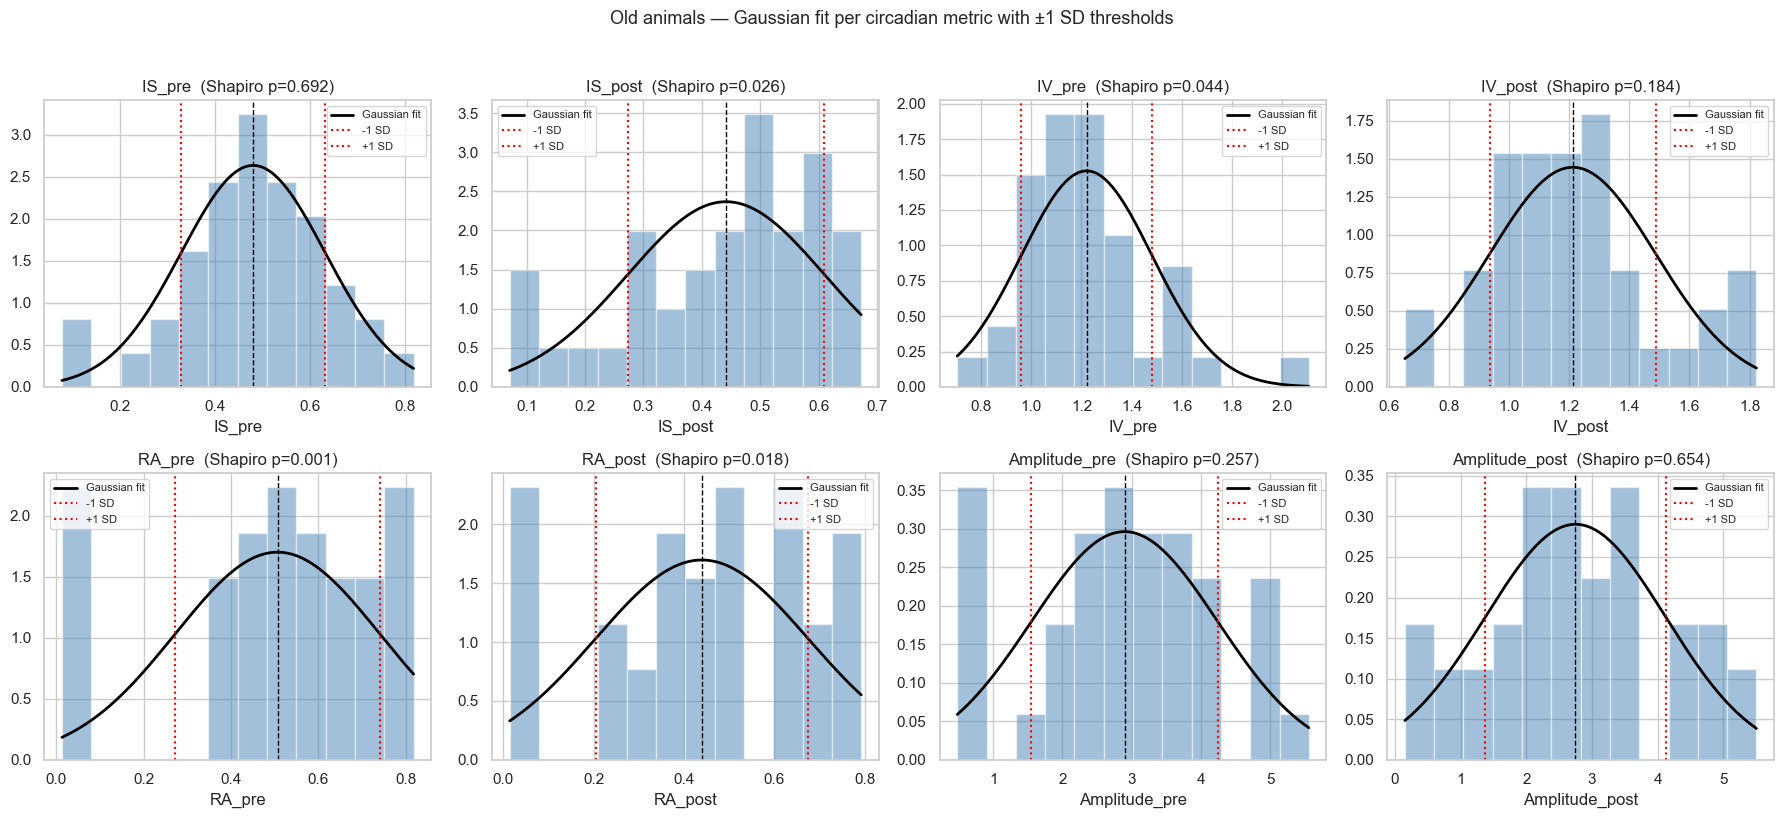

,metric,n,mean,sd,shapiro_W,shapiro_p
0,IS_pre,40,0.480,0.151,0.980,0.692
1,IS_post,40,0.442,0.168,0.936,0.026
2,IV_pre,40,1.221,0.261,0.943,0.044
3,IV_post,40,1.212,0.276,0.961,0.184
4,RA_pre,40,0.506,0.234,0.886,0.001
5,RA_post,40,0.439,0.235,0.931,0.018
6,Amplitude_pre,40,2.897,1.345,0.965,0.257
7,Amplitude_post,40,2.749,1.375,0.979,0.654


In [2]:
CIRC_METRICS = ['IS_pre', 'IS_post', 'IV_pre', 'IV_post', 'RA_pre', 'RA_post', 'Amplitude_pre', 'Amplitude_post']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
shapiro_results = []
for ax, m in zip(axes.ravel(), CIRC_METRICS):
    x = old[m].dropna().values
    mu, sd = x.mean(), x.std(ddof=1)
    ax.hist(x, bins=12, density=True, alpha=0.5, color="steelblue",
            edgecolor="white")
    xs = np.linspace(x.min(), x.max(), 200)
    ax.plot(xs, stats.norm.pdf(xs, mu, sd), "k-", lw=2, label="Gaussian fit")
    ax.axvline(mu, color="black", ls="--", lw=1)
    ax.axvline(mu - sd, color="red", ls=":", lw=1.5, label="-1 SD")
    ax.axvline(mu + sd, color="red", ls=":", lw=1.5, label="+1 SD")
    W, p = stats.shapiro(x)
    shapiro_results.append({"metric": m, "n": len(x), "mean": mu, "sd": sd,
                             "shapiro_W": W, "shapiro_p": p})
    ax.set_title(f"{m}  (Shapiro p={p:.3f})")
    ax.set_xlabel(m)
    ax.legend(fontsize=8)
plt.suptitle("Old animals — Gaussian fit per circadian metric with ±1 SD thresholds",
             y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

pd.DataFrame(shapiro_results).round(3)


### ⚠️ Problem 1 — Normality is assumed but not always satisfied

The Gaussian overlay is only a meaningful model of the data *if the data are actually
Gaussian*. Any metric with Shapiro-Wilk `p < 0.05` above is violating that assumption,
so the ±1 SD thresholds don't correspond to the tail probabilities we'd expect. With
only ~40–50 old animals, the test is already underpowered — genuine non-normality is
easy to miss.

## Step 2 — Label each animal per metric (vulnerable vs resilient)

In [3]:
labels = pd.DataFrame({"ID": old["ID"].values})
for m in CIRC_METRICS:
    x = old[m]
    mu, sd = x.mean(), x.std(ddof=1)
    z = (x - mu) / sd
    labels[m] = np.where(z.abs() > 1, "vulnerable", "resilient")

# Proportion outside ±1 SD per metric
pct_outside = (labels[CIRC_METRICS] == "vulnerable").mean().mul(100).round(1)
pct_outside.to_frame("% labelled vulnerable (|z|>1)")


,% labelled vulnerable (|z|>1)
IS_pre,27.5
IS_post,35.0
IV_pre,27.5
IV_post,30.0
RA_pre,30.0
RA_post,32.5
Amplitude_pre,30.0
Amplitude_post,37.5


### ⚠️ Problem 2 — "Outside 1 SD" is not *extreme*

Under a normal distribution, **~32% of observations fall outside ±1 SD** — that's the
middle of the tail, not an outlier region. The table above shows exactly that: most
metrics label roughly a third of animals as "vulnerable". Calling routine tail
variability "vulnerability" inflates the class, blurs biology, and guarantees the
group contains many typical animals. Conventional outlier thresholds are ±2 SD
(~5%) or direct percentile cutoffs.

## Step 3 — Both tails get the same label: biologically opposite animals lumped together

In [4]:
# For each metric, show mean behaviour for animals in the LOW tail vs HIGH tail vs middle.
# If the two tails behave differently, the "vulnerable" label is hiding opposite phenotypes.
rows = []
for m in CIRC_METRICS:
    mu, sd = old[m].mean(), old[m].std(ddof=1)
    z = (old[m] - mu) / sd
    tail_low  = old[z < -1]
    tail_high = old[z >  1]
    for bm, bm_label in [("barnes_entries_t6", "Barnes entries"),
                         ("learning_slope", "Learning slope"),
                         ("DI_duration", "NOR DI")]:
        rows.append({
            "metric": m, "behaviour": bm_label,
            "LOW-tail mean":  tail_low[bm].mean(),
            "HIGH-tail mean": tail_high[bm].mean(),
            "n_low": tail_low[bm].notna().sum(),
            "n_high": tail_high[bm].notna().sum(),
        })
pd.DataFrame(rows).round(3)


,metric,behaviour,LOW-tail mean,HIGH-tail mean,n_low,n_high
0,IS_pre,Barnes entries,1.600,2.833,5,6
1,IS_pre,Learning slope,0.045,0.063,5,6
2,IS_pre,NOR DI,0.570,0.353,5,6
3,IS_post,Barnes entries,2.333,3.125,6,8
4,IS_post,Learning slope,-0.014,0.017,6,8
5,IS_post,NOR DI,0.522,0.500,6,7
6,IV_pre,Barnes entries,3.800,1.500,5,6
7,IV_pre,Learning slope,0.010,0.005,5,6
8,IV_pre,NOR DI,0.416,0.594,4,6
9,IV_post,Barnes entries,2.500,2.143,4,7


/var/folders/t3/h94sjlkj52n5m4ht71d3mwmw0000gn/T/ipykernel_75671/3700705926.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=old_plot, x="group", y=bm,
/var/folders/t3/h94sjlkj52n5m4ht71d3mwmw0000gn/T/ipykernel_75671/3700705926.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=old_plot, x="group", y=bm,
/var/folders/t3/h94sjlkj52n5m4ht71d3mwmw0000gn/T/ipykernel_75671/3700705926.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=old_plot, x="group", y=bm,


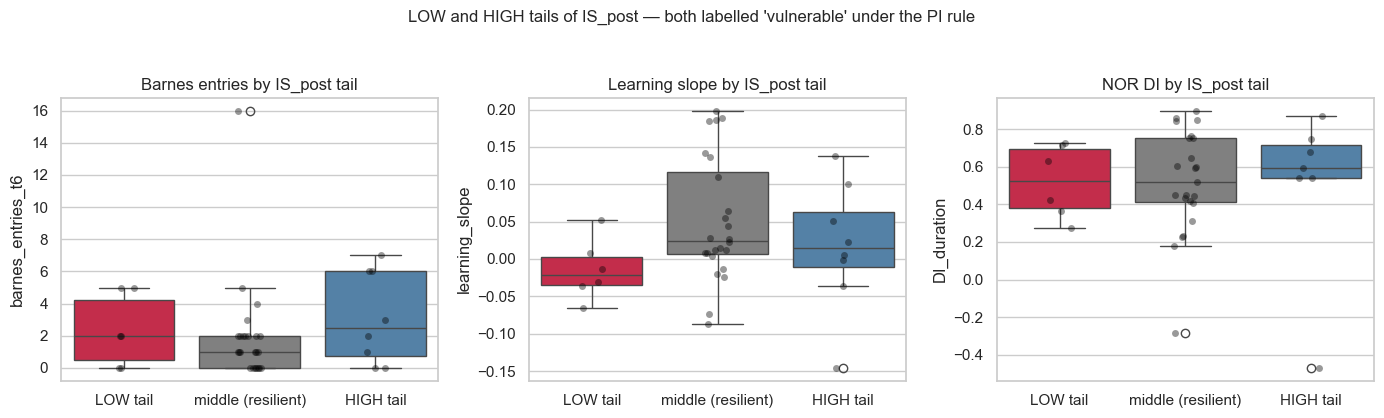

In [5]:
# Visual: for IS_post (representative), plot behaviour scores by tail
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
m = "IS_post"
mu, sd = old[m].mean(), old[m].std(ddof=1)
z = (old[m] - mu) / sd
group = np.where(z < -1, "LOW tail", np.where(z > 1, "HIGH tail", "middle (resilient)"))
old_plot = old.assign(group=group)
for ax, (bm, bm_label) in zip(axes, [("barnes_entries_t6", "Barnes entries"),
                                      ("learning_slope", "Learning slope"),
                                      ("DI_duration", "NOR DI")]):
    sns.boxplot(data=old_plot, x="group", y=bm,
                order=["LOW tail", "middle (resilient)", "HIGH tail"],
                ax=ax, palette=["crimson", "grey", "steelblue"])
    sns.stripplot(data=old_plot, x="group", y=bm,
                  order=["LOW tail", "middle (resilient)", "HIGH tail"],
                  ax=ax, color="black", alpha=0.4)
    ax.set_title(bm_label + " by IS_post tail")
    ax.set_xlabel("")
plt.suptitle("LOW and HIGH tails of IS_post — both labelled 'vulnerable' under the PI rule",
             y=1.04, fontsize=12)
plt.tight_layout()
plt.show()


### ⚠️ Problem 3 — The two tails are biologically opposite

For metrics with a known health direction this is clearest:
- `IS` (interdaily stability) — **low IS = fragmented rhythm = dysfunction**; high IS = healthy.
- `IV` (intradaily variability) — **high IV = fragmented = dysfunction**; low IV = healthy.
- `RA`/`Amplitude` — **low = weak rhythm = dysfunction**; high = strong rhythm.

Under the PI rule, animals at the *healthy* end of IS and the *unhealthy* end of IS
both end up in the "vulnerable" bucket. The boxplots above make this vivid:
the two tails are typically on **opposite sides** of the middle on the behavioural
outcomes. Pooling them destroys the biological signal we are trying to find.

## Step 4 — Cross-metric disagreement: the same animal is labelled differently by different metrics

In [6]:
# How often do the per-metric labels for the same animal agree?
from itertools import combinations
pairs = []
for a, b in combinations(CIRC_METRICS, 2):
    agree = (labels[a] == labels[b]).mean() * 100
    pairs.append({"metric A": a, "metric B": b, "% animals labelled the same": round(agree, 1)})
pd.DataFrame(pairs).sort_values("% animals labelled the same")


,metric A,metric B,% animals labelled the same
4,IS_pre,RA_post,55.0
6,IS_pre,Amplitude_post,60.0
21,IV_post,Amplitude_post,62.5
1,IS_pre,IV_pre,65.0
17,IV_pre,Amplitude_post,65.0
15,IV_pre,RA_post,65.0
0,IS_pre,IS_post,67.5
2,IS_pre,IV_post,67.5
3,IS_pre,RA_pre,67.5
5,IS_pre,Amplitude_pre,67.5


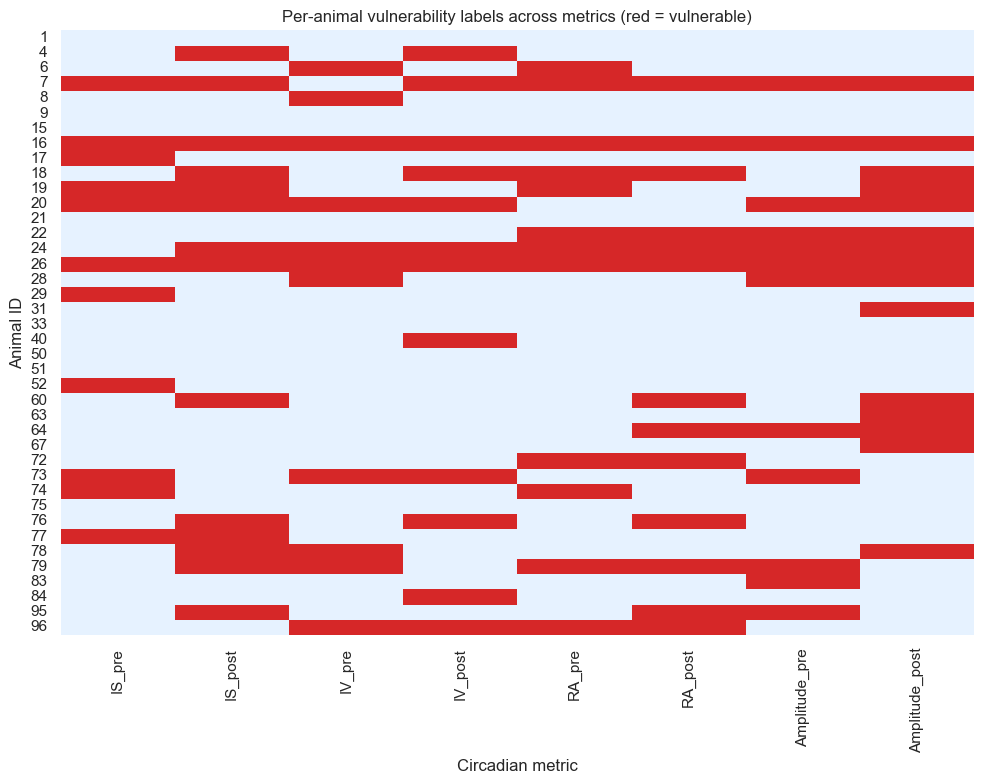

Distribution of number of metrics on which each animal is 'vulnerable':
0     8
1    10
2     5
3     6
4     4
5     2
6     1
7     2
8     2


In [7]:
# Heatmap: animals × metrics, vulnerable (1) vs resilient (0)
bin_mat = (labels[CIRC_METRICS] == "vulnerable").astype(int).values
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(bin_mat, cmap=["#e6f2ff", "#d62728"], cbar=False,
            xticklabels=CIRC_METRICS,
            yticklabels=labels["ID"].values, ax=ax)
ax.set_xlabel("Circadian metric")
ax.set_ylabel("Animal ID")
ax.set_title("Per-animal vulnerability labels across metrics (red = vulnerable)")
plt.tight_layout()
plt.show()

# How many metrics is each animal flagged on?
n_flagged = (labels[CIRC_METRICS] == "vulnerable").sum(axis=1)
print("Distribution of number of metrics on which each animal is 'vulnerable':")
print(n_flagged.value_counts().sort_index().to_string())


### ⚠️ Problem 4 — No coherent classification

An animal flagged as vulnerable on `IS_pre` might be resilient on `IS_post`, `IV_post`,
`RA_pre`. There is no single answer to "is this animal vulnerable?". The PI's plan as
stated does not specify how to combine these — so any downstream group comparison is
conditional on the arbitrary choice of which metric we use to define the groups. This
is a researcher-degrees-of-freedom problem: with 8 metric choices and 3 behavioural
outcomes, at α = 0.05 we expect ~1.2 false positives just by chance.

## Step 5 — Run the behavioural comparison as the PI proposed, per metric

In [8]:
from scipy.stats import mannwhitneyu

def cohens_d(a, b):
    a, b = np.asarray(a), np.asarray(b)
    na, nb = len(a), len(b)
    sp = np.sqrt(((na-1)*a.var(ddof=1) + (nb-1)*b.var(ddof=1)) / (na+nb-2))
    return (a.mean() - b.mean()) / sp if sp > 0 else np.nan

results = []
for m in CIRC_METRICS:
    vul = old[labels[m].values == "vulnerable"]
    res = old[labels[m].values == "resilient"]
    for bm, bm_label in [("barnes_entries_t6", "Barnes entries"),
                         ("learning_slope", "Learning slope"),
                         ("DI_duration", "NOR DI")]:
        a = vul[bm].dropna().values
        b = res[bm].dropna().values
        if len(a) < 2 or len(b) < 2:
            continue
        U, p = mannwhitneyu(a, b, alternative="two-sided")
        d = cohens_d(a, b)
        results.append({
            "circadian metric": m, "behaviour": bm_label,
            "n_vul": len(a), "n_res": len(b),
            "mean_vul": a.mean(), "mean_res": b.mean(),
            "Cohen_d": d, "MWU_p": p,
        })
res_df = pd.DataFrame(results).round(3)
res_df


,circadian metric,behaviour,n_vul,n_res,mean_vul,mean_res,Cohen_d,MWU_p
0,IS_pre,Barnes entries,11,27,2.273,2.296,-0.008,0.804
1,IS_pre,Learning slope,11,27,0.055,0.025,0.365,0.385
2,IS_pre,NOR DI,11,25,0.452,0.544,-0.311,0.583
3,IS_post,Barnes entries,14,24,2.786,2.000,0.260,0.220
4,IS_post,Learning slope,14,24,0.004,0.051,-0.606,0.082
5,IS_post,NOR DI,13,23,0.510,0.519,-0.030,0.921
6,IV_pre,Barnes entries,11,27,2.545,2.185,0.118,0.428
7,IV_pre,Learning slope,11,27,0.007,0.044,-0.466,0.260
8,IV_pre,NOR DI,10,26,0.523,0.513,0.034,0.685
9,IV_post,Barnes entries,11,27,2.273,2.296,-0.008,0.656


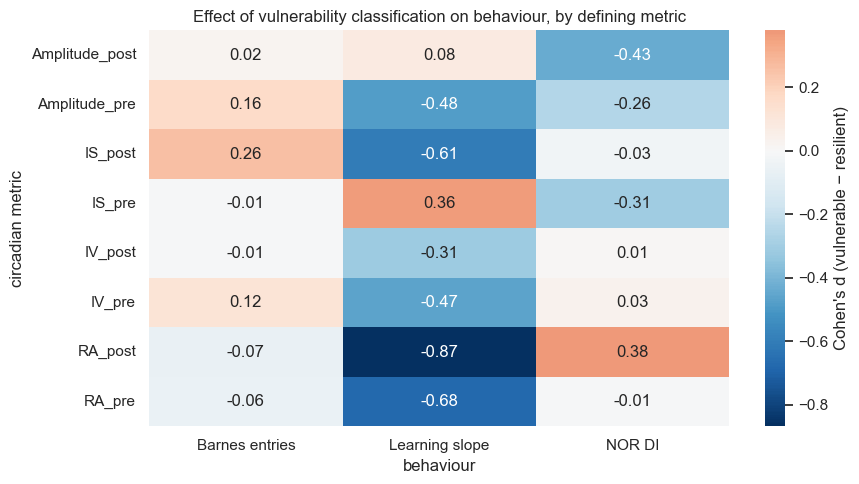

In [9]:
# Visualise Cohen's d across metric choices for each behaviour — to show how the
# conclusion ping-pongs depending on which metric defines the split.
pivot = res_df.pivot(index="circadian metric", columns="behaviour", values="Cohen_d")
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label": "Cohen's d (vulnerable − resilient)"})
ax.set_title("Effect of vulnerability classification on behaviour, by defining metric")
plt.tight_layout()
plt.show()


### ⚠️ Problem 5 — Results flip depending on which metric you use

The heatmap typically shows positive and negative Cohen's *d* for the *same* behaviour
depending on whether the split was made on `IS_pre` vs `IV_post` vs `RA_post`, etc.
There is no principled way to pick among these — whichever the PI shows the reader is
effectively a post-hoc choice, and the others contradict it.

### ⚠️ Problem 6 — Dichotomising a continuous variable wastes information

Even if we fix everything above, turning a continuous z-score into a binary label
throws away the magnitude of deviation. MacCallum et al. (2002) and others show this
typically reduces power to detect a real effect by the equivalent of losing ~30% of
your sample. With an old-animal n of ~45, this is not a subset we can afford to shrink.


## Summary — why this approach is not defensible

| # | Problem | Why it matters |
|---|---------|----------------|
| 1 | Normality assumed, not tested before labelling | Gaussian tails are wrong for non-normal metrics |
| 2 | 1 SD is not "extreme" — ~32% of animals by construction | Inflates the "vulnerable" class with typical animals |
| 3 | Both tails share a label | Biologically opposite phenotypes are pooled |
| 4 | Per-metric labels disagree across metrics | No coherent classification; researcher-degrees-of-freedom |
| 5 | Behavioural effects flip across metric choices | Conclusion depends on an arbitrary pick |
| 6 | Dichotomising a continuous variable | Loses power in an already-small subsample |

Notebook 2 (`02_composite_directional_approach.ipynb`) implements a directional
composite-score alternative that fixes 2, 3, and 4; and adds a continuous-correlation
sanity check to avoid 6.


---
## Sex-stratified view — Old Males vs Old Females

The main analysis above pooled all 40 old animals. Because sex is the strongest
determinant of circadian phenotype in this cohort and the Old-Male subgroup shows
an FDR-significant locomotor deficit, the same PI-approach analysis is re-run below
separately for Old Females and Old Males. If the per-metric ±1 SD approach is
genuinely unstable (as Sections 1–5 argued), splitting by sex should make the
instability *more* obvious, not less.


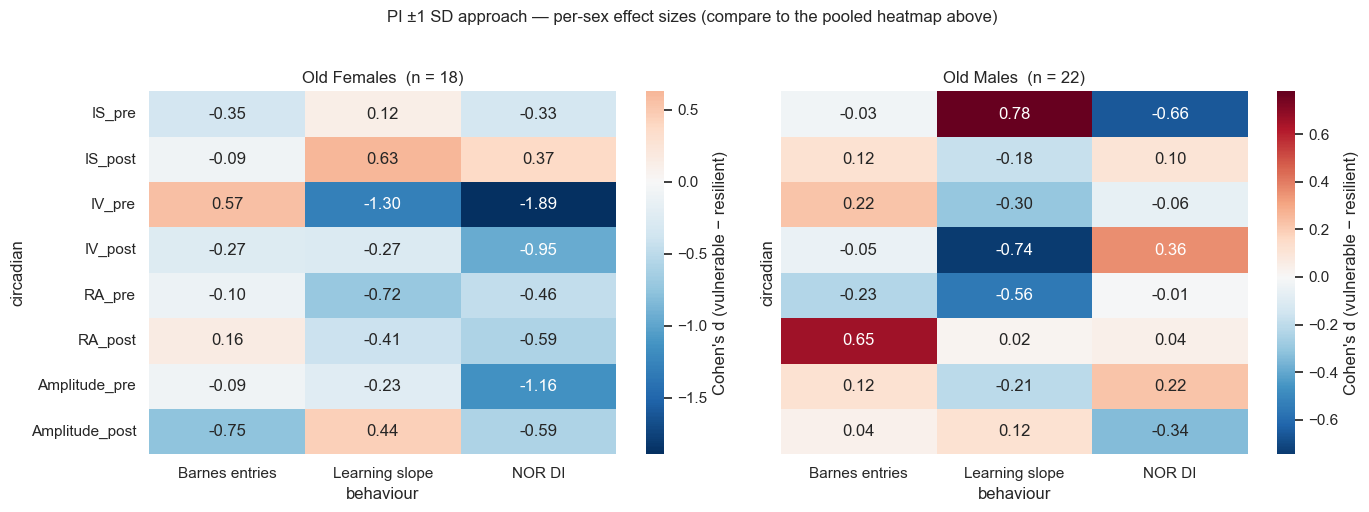

In [10]:
# Cohen's d heatmap of (vulnerable - resilient) on each behaviour, per circadian metric,
# computed independently within Old Females and Old Males.
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, sex in zip(axes, ["Female", "Male"]):
    sub = old[old["Sex_new"] == sex].copy()
    rows = []
    for m in CIRC_METRICS:
        mu, sd = sub[m].mean(), sub[m].std(ddof=1)
        if not np.isfinite(sd) or sd == 0: continue
        is_vul = (sub[m] - mu).abs() / sd > 1
        for bm, bm_label in [("barnes_entries_t6", "Barnes entries"),
                             ("learning_slope", "Learning slope"),
                             ("DI_duration", "NOR DI")]:
            a = sub.loc[is_vul, bm].dropna().values
            b = sub.loc[~is_vul, bm].dropna().values
            if len(a) < 2 or len(b) < 2:
                rows.append({"circadian": m, "behaviour": bm_label, "Cohen_d": np.nan})
                continue
            na, nb = len(a), len(b)
            sp = np.sqrt(((na-1)*a.var(ddof=1) + (nb-1)*b.var(ddof=1)) / (na+nb-2))
            d = (a.mean() - b.mean()) / sp if sp > 0 else np.nan
            rows.append({"circadian": m, "behaviour": bm_label, "Cohen_d": d})
    pivot = pd.DataFrame(rows).pivot(index="circadian", columns="behaviour", values="Cohen_d")
    pivot = pivot.reindex(CIRC_METRICS)
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
                cbar_kws={"label": "Cohen's d (vulnerable − resilient)"})
    ax.set_title(f"Old {sex}s  (n = {len(sub)})")
plt.suptitle("PI ±1 SD approach — per-sex effect sizes (compare to the pooled heatmap above)",
             y=1.02, fontsize=12)
plt.tight_layout(); plt.show()


**What to look for.** If the two heatmaps share sign and approximate magnitude in
most cells, the pooled result in Section 5 was representative of both sexes. If they
differ sharply (cells red in one, blue in the other), that is *more* evidence the
per-metric classification is unstable — now it's not just different across metrics
but different across sexes for the same metric. Either way, the conclusion from the
pooled section stands: the PI's approach does not deliver a stable classification.

Note: the samples shrink to Old Females n ≈ 18 and Old Males n ≈ 22. At these sizes
even the Cohen's *d* point estimates are noisy and should not be over-interpreted —
which is itself the cautionary point.
